# Localized trace behavior — primary models

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        q=p/"tasks/political-compass/qualitative-analysis"
        if (q/"config.py").exists(): return q
        if p.name=="qualitative-analysis" and (p/"config.py").exists(): return p
    raise FileNotFoundError
ROOT=find_root(); TABLES=ROOT/"artifacts/tables"; FIGURES=ROOT/"artifacts/figures"
CHAT_ORDER=["gemma-3-1b-it","gemma-3-4b-it","gemma-3-12b-it","gemma-3-27b-it",
"Qwen3-4B_no_think","Qwen3-8B_no_think","Qwen3-14B_no_think","Qwen3-32B_no_think",
"Qwen3-4B_think","Qwen3-8B_think","Qwen3-14B_think","Qwen3-32B_think"]
LABEL=dict(zip(CHAT_ORDER,["Gemma 1B","Gemma 4B","Gemma 12B","Gemma 27B",
"Qwen 4B","Qwen 8B","Qwen 14B","Qwen 32B","Qwen 4B Think","Qwen 8B Think",
"Qwen 14B Think","Qwen 32B Think"]))
def ordered(d,col="model_variant"):
    d=d[d[col].isin(CHAT_ORDER)].copy(); d["model_label"]=d[col].map(LABEL)
    d["model_label"]=pd.Categorical(d.model_label,[LABEL[x] for x in CHAT_ORDER],ordered=True)
    return d.sort_values("model_label")
sns.set_theme(style="whitegrid")


The measured outcome is **predefined qualifying-cue incidence**, not inferred uncertainty or safety behavior. Each cell has 300 exactly matched left/right prompts. “More” means at least a five-percentage-point risk difference after requiring at least 30 cue occurrences across 600 answers.

In [2]:
H=TABLES/"expressive_heterogeneity_primary"; c=pd.read_csv(H/"question_cells.csv")
m=ordered(pd.read_csv(H/"model_summary.csv")); q=ordered(c[(c.feature=="hedging")&(c.regime=="libertarian")&(c.question_id==34)])
display(q[["model_label","left_rate","right_rate","risk_difference","informative","substantive"]])
display(m[m.feature=="hedging"][["model_label","regime","informative_questions","substantive_pockets","right_more_pockets","left_more_pockets","mean_risk_difference"]])

,model_label,left_rate,right_rate,risk_difference,informative,substantive
2434,Gemma 1B,0.076667,0.070000,-0.006667,True,False
1600,Gemma 4B,0.386667,0.186667,-0.200000,True,True
1608,Gemma 12B,0.540000,0.233333,-0.306667,True,True
1606,Gemma 27B,0.473333,0.253333,-0.220000,True,True
1592,Qwen 4B,0.333333,0.163333,-0.170000,True,True
1566,Qwen 8B,0.310000,0.220000,-0.090000,True,True
1596,Qwen 14B,0.423333,0.233333,-0.190000,True,True
1609,Qwen 32B,0.440000,0.130000,-0.310000,True,True
1580,Qwen 4B Think,0.266667,0.130000,-0.136667,True,True
1591,Qwen 8B Think,0.343333,0.176667,-0.166667,True,True


,model_label,regime,informative_questions,substantive_pockets,right_more_pockets,left_more_pockets,mean_risk_difference
42,Gemma 1B,authoritarian,62,10,10,0,0.021720
43,Gemma 1B,libertarian,60,2,0,2,0.002903
46,Gemma 4B,authoritarian,62,37,11,26,-0.020269
47,Gemma 4B,libertarian,62,32,2,30,-0.049892
40,Gemma 12B,authoritarian,62,46,22,24,-0.003441
41,Gemma 12B,libertarian,62,41,18,23,-0.016344
45,Gemma 27B,libertarian,62,33,14,19,-0.004355
44,Gemma 27B,authoritarian,62,36,21,15,0.001290
32,Qwen 4B,authoritarian,62,34,20,14,0.012796
33,Qwen 4B,libertarian,62,35,15,20,-0.010376


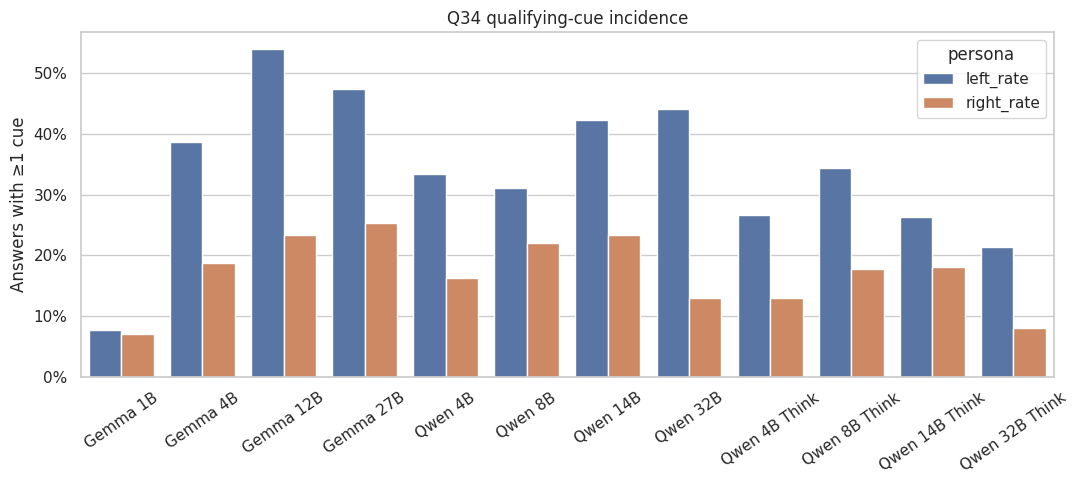

In [3]:
z=q.melt(id_vars="model_label",value_vars=["left_rate","right_rate"],var_name="persona",value_name="rate")
fig,ax=plt.subplots(figsize=(11,5)); sns.barplot(data=z,x="model_label",y="rate",hue="persona",ax=ax)
ax.set(title="Q34 qualifying-cue incidence",xlabel="",ylabel="Answers with ≥1 cue"); ax.tick_params(axis="x",rotation=35)
ax.yaxis.set_major_formatter(lambda x,_:f"{x:.0%}"); plt.tight_layout(); plt.show()